In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
import os

print("Current Working Directory:", os.getcwd())

Current Working Directory: c:\Users\krupa\OneDrive\Desktop\mutualfundanalytics\notebooks


In [4]:
import os

print(os.listdir("../data/processed"))

['02_nav_history.csv', 'alpha_beta.csv', 'cagr_comparison.csv', 'cleaned_01_fund_master.csv', 'fund_scorecard.csv', 'investor_transactions_clean.csv', 'maximum_drawdown.csv', 'nav_history_clean.csv', 'processed_01_fund_master.csv', 'scheme_performance_clean.csv', 'sharpe_ratio.csv', 'sortino_ratio.csv', 'tracking_error.csv']


In [5]:
funds = pd.read_csv("../data/processed/processed_01_fund_master.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [6]:
print("Funds Columns")
print(funds.columns)

print("\nNAV Columns")
print(nav.columns)

print("\nTransactions Columns")
print(transactions.columns)

Funds Columns
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

NAV Columns
Index(['amfi_code', 'date', 'nav'], dtype='object')

Transactions Columns
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


In [7]:
import os
print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'processed']


In [8]:
funds = pd.read_csv("../data/processed/processed_01_fund_master.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [9]:
print("Funds")
print(funds.columns)

print("\nNAV")
print(nav.columns)

print("\nTransactions")
print(transactions.columns)

print("\nPortfolio")
print(portfolio.columns)

Funds
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='object')

NAV
Index(['amfi_code', 'date', 'nav'], dtype='object')

Transactions
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

Portfolio
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')


In [10]:
# Convert date column to datetime
nav['date'] = pd.to_datetime(nav['date'])

# Sort values
nav = nav.sort_values(['amfi_code', 'date'])

# Calculate daily returns
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Remove missing returns
returns = nav.dropna(subset=['daily_return'])

# Calculate VaR and CVaR
risk_metrics = []

for fund, group in returns.groupby('amfi_code'):
    var95 = np.percentile(group['daily_return'], 5)
    cvar95 = group[group['daily_return'] <= var95]['daily_return'].mean()

    risk_metrics.append({
        'amfi_code': fund,
        'VaR_95': var95,
        'CVaR_95': cvar95
    })

risk_df = pd.DataFrame(risk_metrics)

# Merge with fund names
risk_df = risk_df.merge(
    funds[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

risk_df = risk_df[['amfi_code', 'scheme_name', 'VaR_95', 'CVaR_95']]

risk_df.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [11]:
risk_df.to_csv("../reports/var_cvar_report.csv", index=False)

print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [12]:
risk_df.sort_values("VaR_95").head(10)

,amfi_code,scheme_name,VaR_95,CVaR_95
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
17,119095,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
39,149324,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
25,120505,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
16,119094,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


In [13]:
# Calculate daily returns again (if not already available)
nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# Rolling 90-day Sharpe Ratio
nav['rolling_sharpe'] = (
    nav.groupby('amfi_code')['daily_return']
       .transform(lambda x: (x.rolling(90).mean() / x.rolling(90).std()) * np.sqrt(252))
)

nav.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


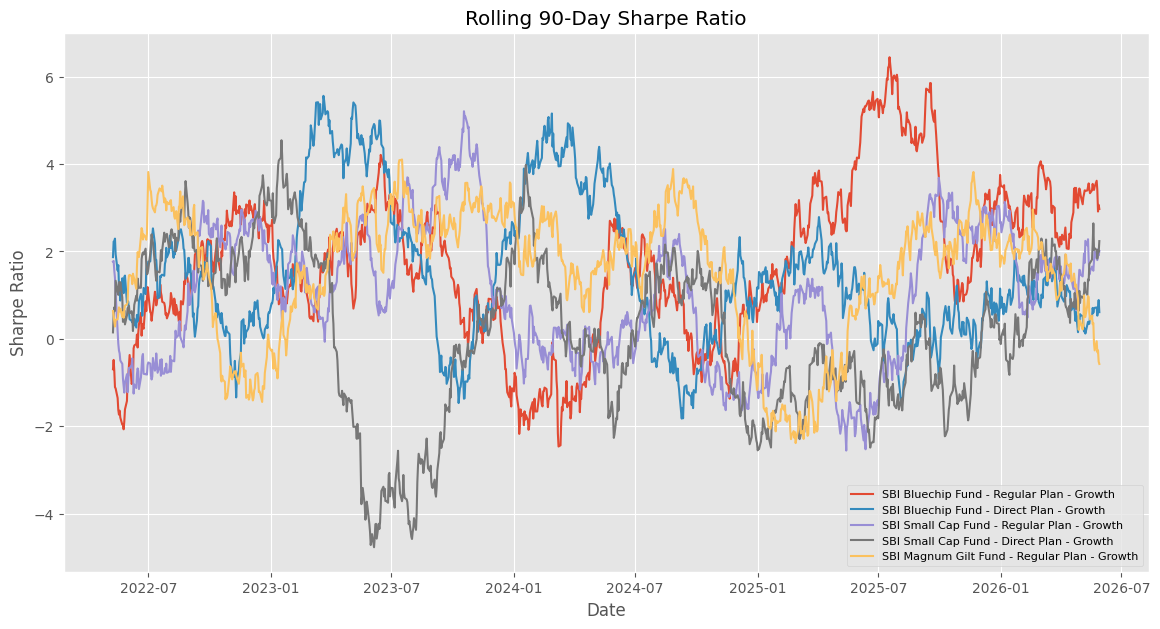

In [14]:
plt.figure(figsize=(14,7))

top5 = funds['amfi_code'].head(5)

for code in top5:
    temp = nav[nav['amfi_code'] == code]
    name = funds.loc[funds['amfi_code'] == code, 'scheme_name'].values[0]
    plt.plot(temp['date'], temp['rolling_sharpe'], label=name)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend(fontsize=8)
plt.grid(True)

plt.savefig("../reports/rolling_sharpe_chart.png", dpi=300)

plt.show()

In [15]:
import os

print(os.listdir("../reports"))

['aum_growth.png', 'bar_chart.png', 'benchmark_comparison.png', 'benchmark_trend.png', 'category_inflows.png', 'data_dictionary.md', 'data_quality_summary.txt', 'folio_count.png', 'nav_trend.png', 'portfolio_holdings.png', 'rolling_sharpe_chart.png', 'sip_trend.png', 'test_report.py', 'top_10_performance.png', 'var_cvar_report.csv']


In [16]:
# Convert transaction date to datetime
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])

# First investment year of each investor
transactions['first_year'] = transactions.groupby('investor_id')['transaction_date'].transform('min').dt.year

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,first_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [17]:
cohort_summary = transactions.groupby('first_year').agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum')
).reset_index()

cohort_summary

,first_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [18]:
# Count investments per fund within each cohort
top_fund = (
    transactions.groupby(['first_year', 'amfi_code'])
    .size()
    .reset_index(name='count')
)

# Select most preferred fund
top_fund = top_fund.loc[top_fund.groupby('first_year')['count'].idxmax()]

# Add fund names
top_fund = top_fund.merge(
    funds[['amfi_code', 'scheme_name']],
    on='amfi_code',
    how='left'
)

top_fund = top_fund[['first_year', 'scheme_name']]

top_fund

,first_year,scheme_name
0,2024,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,SBI Small Cap Fund - Direct Plan - Growth


In [19]:
cohort_report = cohort_summary.merge(top_fund, on='first_year')

cohort_report

,first_year,avg_sip_amount,total_invested,scheme_name
0,2024,107422.541832,3491125187,Mirae Asset Emerging Bluechip Fund - Regular -...
1,2025,109158.577061,30455243,SBI Small Cap Fund - Direct Plan - Growth


In [20]:
cohort_report.to_csv("../reports/investor_cohort_report.csv", index=False)

print("Investor Cohort Report saved successfully!")

Investor Cohort Report saved successfully!


In [21]:
transactions = transactions.sort_values(['investor_id', 'transaction_date'])

In [22]:
transactions['previous_date'] = transactions.groupby('investor_id')['transaction_date'].shift(1)

transactions['gap_days'] = (
    transactions['transaction_date'] - transactions['previous_date']
).dt.days

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,first_year,previous_date,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaT,NaN
24079,INV000001,2025-01-14,148569,LUMPSUM,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,2024-11-04,71.0
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,2025-01-14,5.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaT,NaN
12522,INV000002,2024-07-14,149323,LUMPSUM,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,2024-03-29,107.0


In [23]:
sip_counts = transactions.groupby('investor_id').size()

eligible = sip_counts[sip_counts >= 6].index

sip_data = transactions[
    transactions['investor_id'].isin(eligible)
]

In [24]:
sip_continuity = sip_data.groupby('investor_id').agg(
    avg_gap_days=('gap_days', 'mean'),
    total_transactions=('transaction_date', 'count')
).reset_index()

sip_continuity.head()

,investor_id,avg_gap_days,total_transactions
0,INV000002,82.800000,6
1,INV000004,53.375000,9
2,INV000005,52.000000,8
3,INV000006,99.000000,6
4,INV000008,50.285714,8


In [25]:
sip_continuity['status'] = np.where(
    sip_continuity['avg_gap_days'] > 35,
    'At-Risk',
    'Regular'
)

sip_continuity.head()

,investor_id,avg_gap_days,total_transactions,status
0,INV000002,82.800000,6,At-Risk
1,INV000004,53.375000,9,At-Risk
2,INV000005,52.000000,8,At-Risk
3,INV000006,99.000000,6,At-Risk
4,INV000008,50.285714,8,At-Risk


In [26]:
sip_continuity.to_csv("../reports/sip_continuity_report.csv", index=False)

print("SIP Continuity Report saved successfully!")

SIP Continuity Report saved successfully!


In [27]:
# HHI Calculation

portfolio['weight_fraction'] = portfolio['weight_pct'] / 100

hhi = (
    portfolio.groupby('amfi_code')['weight_fraction']
    .apply(lambda x: (x ** 2).sum())
    .reset_index(name='HHI')
)

# Merge with fund names and category
hhi = hhi.merge(
    funds[['amfi_code', 'scheme_name', 'category']],
    on='amfi_code',
    how='left'
)

# Keep only equity funds
equity_hhi = hhi[
    hhi['category'].str.contains('Equity', case=False, na=False)
]

equity_hhi = equity_hhi.sort_values('HHI', ascending=False)

equity_hhi.head(10)

,amfi_code,HHI,scheme_name,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Equity


In [28]:
equity_hhi.to_csv("../reports/sector_hhi_report.csv", index=False)

print("Sector HHI Report saved successfully!")

Sector HHI Report saved successfully!


In [29]:
cohort_report.to_csv("../reports/investor_cohort_report.csv", index=False)

print("Investor Cohort Report saved successfully!")

Investor Cohort Report saved successfully!


# Advanced Insights

## 1. Historical VaR & CVaR
The Historical VaR (95%) and CVaR analysis identified funds with the highest downside risk. Funds with more negative VaR and CVaR values experienced larger losses during adverse market conditions.

## 2. Rolling 90-Day Sharpe Ratio
The rolling Sharpe ratio showed how risk-adjusted returns changed over time. Funds with consistently higher Sharpe ratios demonstrated better performance relative to the risk taken.

## 3. Investor Cohort Analysis
Investor cohorts grouped by their first investment year revealed differences in average SIP amounts, total investments, and preferred mutual fund schemes across cohorts.

## 4. SIP Continuity Analysis
Investors with an average gap of more than 35 days between SIP transactions were classified as "At-Risk", helping identify investors who may discontinue systematic investments.

## 5. Sector HHI Concentration
The Herfindahl-Hirschman Index (HHI) measured portfolio concentration. Higher HHI values indicate portfolios concentrated in fewer holdings, while lower values indicate better diversification.

In [30]:
import os

print(os.listdir("../reports"))

['aum_growth.png', 'bar_chart.png', 'benchmark_comparison.png', 'benchmark_trend.png', 'category_inflows.png', 'data_dictionary.md', 'data_quality_summary.txt', 'folio_count.png', 'investor_cohort_report.csv', 'nav_trend.png', 'portfolio_holdings.png', 'rolling_sharpe_chart.png', 'sector_hhi_report.csv', 'sip_continuity_report.csv', 'sip_trend.png', 'test_report.py', 'top_10_performance.png', 'var_cvar_report.csv']


cohort_report.to_csv("../reports/investor_cohort_report.csv", index=False)

print("Investor Cohort Report saved successfully!")